# Reto 06 - Aumento de datos con GANs

## Generación de pasajeros sintéticos del Titanic para enriquecer un conjunto de datos pequeño

> **Fuente del problema:** [Titanic Dataset](https://www.kaggle.com/datasets/yasserh/titanic-dataset)
> publicado en **Kaggle** por *Yasser H.*, a partir de los registros históricos de los pasajeros del **RMS Titanic**,
> el transatlántico que se hundió el **15 de abril de 1912** tras chocar con un iceberg en su viaje inaugural.

### El problema

El conjunto de datos describe a **891 pasajeros** del Titanic, de los cuales solo **342 sobrevivieron** (alrededor del **38.4 %**) y
**549 no lo hicieron** (**61.6 %**). Es un conjunto de datos **pequeño** y **tabular**, con una mezcla de variables numéricas y
categóricas, valores faltantes y una relación no trivial entre las características de cada pasajero (clase, sexo, edad, tarifa, etc.)
y su probabilidad de supervivencia. A diferencia de las imágenes, donde el aumento de datos se resuelve con rotaciones, recortes o
cambios de brillo, en datos tabulares **no existen transformaciones triviales que preserven la semántica** de un registro: modificar
la edad o la tarifa de un pasajero sin cuidado puede producir combinaciones imposibles o incoherentes.

Con tan pocos ejemplos, los modelos de aprendizaje profundo tienden al *sobreajuste*, por lo que este conjunto de datos es un buen
escenario para explorar el **aumento de datos** y las **redes generativas adversarias (GANs)** como mecanismo para sintetizar
registros nuevos y realistas que sigan la distribución conjunta de los pasajeros originales.

### Objetivo

1. Explorar el conjunto de datos, identificar los **valores faltantes**, el tipo de cada variable y el **desbalance moderado** entre
   sobrevivientes y no sobrevivientes.
2. Preprocesar las variables (imputación, codificación de categóricas y escalamiento) para dejarlas en un formato adecuado para una red
   neuronal.
3. Entrenar una **GAN** (generador y discriminador) que aprenda la distribución de los pasajeros y produzca **datos sintéticos**.
4. Evaluar la calidad de los datos sintéticos (comparación de distribuciones).

### Estructura de los datos

El conjunto de datos se distribuye como un único archivo `Titanic-Dataset.csv` con **891 filas** y **12 columnas**:

| Columna | Tipo | Descripción |
|---|---|---|
| `PassengerId` | int | Identificador único del pasajero (no aporta información predictiva) |
| `Survived` | int | Variable objetivo: `1` si el pasajero sobrevivió, `0` en caso contrario |
| `Pclass` | int | Clase del boleto: `1` (primera), `2` (segunda) o `3` (tercera); funciona como indicador del nivel socioeconómico |
| `Name` | str | Nombre del pasajero, incluye el título (*Mr.*, *Mrs.*, *Miss*, etc.) |
| `Sex` | str | Sexo del pasajero (`male` / `female`) |
| `Age` | float | Edad en años; fraccionaria para menores de un año |
| `SibSp` | int | Número de hermanos o cónyuges a bordo |
| `Parch` | int | Número de padres o hijos a bordo |
| `Ticket` | str | Número de boleto |
| `Fare` | float | Tarifa pagada por el pasajero |
| `Cabin` | str | Número de camarote |
| `Embarked` | str | Puerto de embarque: `C` (Cherbourg), `Q` (Queenstown) o `S` (Southampton) |

La combinación de un tamaño reducido, variables heterogéneas y valores faltantes hace de este conjunto de datos un caso de estudio
clásico, y a la vez un reto interesante para generar datos sintéticos **tabulares** que conserven las relaciones entre variables.

In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "1.0"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

import keras
import logging
import warnings


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf


from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

tf.get_logger().setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

warnings.filterwarnings("ignore", category=UserWarning)

AUTOTUNE = tf.data.AUTOTUNE

print(
    "Keras:",
    keras.__version__,
    "| backend:",
    keras.backend.backend(),
    "| GPUs:",
    tf.config.list_physical_devices("GPU"),
)

Keras: 3.15.1 | backend: tensorflow | GPUs: []


In [2]:
seed = 42
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

In [3]:
# Read the dataset
titanic_df = pd.read_csv("../data/titanic-dataset/Titanic-Dataset.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
dup = titanic_df.duplicated()

print(f"Duplicated rows: {dup.sum()}")

Duplicated rows: 0


In [5]:
nans = titanic_df.isna()

print(f"Rows with NaN: {nans.sum()}")

Rows with NaN: PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
titles_dict = {
    "Capt": "Other",
    "Major": "Other",
    "Jonkheer": "Other",
    "Don": "Other",
    "Sir": "Other",
    "Dr": "Other",
    "Rev": "Other",
    "Countess": "Other",
    "Dona": "Other",
    "Mme": "Mrs",
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mr": "Mr",
    "Mrs": "Mrs",
    "Miss": "Miss",
    "Master": "Master",
    "Lady": "Other",
}

In [7]:
titanic_df["Title"] = titanic_df["Name"].str.extract("([A-Za-z]+)\\.", expand=False)
titanic_df["Name"] = titanic_df["Name"].str.replace(
    {k + ".": "" for k, v in titles_dict.items()}
)
titanic_df["Title"] = titanic_df["Title"].map(titles_dict)
titanic_df["Title"] = titanic_df["Title"].fillna("Mr")

titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1

titanic_df.drop("SibSp", axis=1, inplace=True)
titanic_df.drop("Parch", axis=1, inplace=True)

titanic_df["HasCabin"] = titanic_df["Cabin"].notna().astype(int)

most_freq = titanic_df["Age"].median()


titanic_df["Age"] = titanic_df["Age"].fillna(most_freq)

titanic_df["Cabin"] = titanic_df["Cabin"].fillna("U").astype(str).str[0]

most_freq = titanic_df["Embarked"].mode()
titanic_df["Embarked"] = titanic_df["Embarked"].fillna(most_freq[0])

titanic_df.drop("PassengerId", axis=1, inplace=True)
titanic_df.drop("Ticket", axis=1, inplace=True)

titanic_df.head()

,Survived,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize,HasCabin
0,0,3,"Braund, Owen Harris",male,22.0,7.2500,U,S,Mr,2,0
1,1,1,"Cumings, John Bradley (Florence Briggs Thayer)",female,38.0,71.2833,C,C,Mrs,2,1
2,1,3,"Heikkinen, Laina",female,26.0,7.9250,U,S,Miss,1,0
3,1,1,"Futrelle, Jacques Heath (Lily May Peel)",female,35.0,53.1000,C,S,Mrs,2,1
4,0,3,"Allen, William Henry",male,35.0,8.0500,U,S,Mr,1,0


In [8]:
nans = titanic_df.isna()

print(f"Rows with NaN:\n{nans.sum()}")

Rows with NaN:
Survived      0
Pclass        0
Name          0
Sex           0
Age           0
Fare          0
Cabin         0
Embarked      0
Title         0
FamilySize    0
HasCabin      0
dtype: int64


In [9]:
titanic_df.dtypes

Survived        int64
Pclass          int64
Name              str
Sex               str
Age           float64
Fare          float64
Cabin             str
Embarked          str
Title             str
FamilySize      int64
HasCabin        int64
dtype: object

In [10]:
titanic_df["Survived"] = titanic_df["Survived"].astype(np.int8)
titanic_df["Pclass"] = titanic_df["Pclass"].astype(np.int8)
titanic_df["HasCabin"] = titanic_df["HasCabin"].astype(np.int8)
titanic_df["Age"] = titanic_df["Age"].astype(np.int8)

In [11]:
pipeline = make_pipeline(
    ColumnTransformer(
        transformers=[
            (
                "ohe",
                OneHotEncoder(drop="first"),
                ["Survived", "Pclass", "Sex", "Cabin", "Embarked", "Title", "HasCabin"],
            ),
            ("nlp", TfidfVectorizer(), "Name"),
            ("std", StandardScaler(), ["Age", "Fare", "FamilySize"]),
        ],
        remainder="drop",
    )
)

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('nlp', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains

In [12]:
X_train = np.asarray(pipeline.fit_transform(titanic_df).todense())  # type: ignore

X_train.shape

(891, 1517)

In [13]:
ct = pipeline.named_steps["columntransformer"]


cond_names = [n for n in ct.output_indices_ if "ohe" in n]

cond_idx = np.concatenate(
    [
        np.arange(ct.output_indices_[n].start, ct.output_indices_[n].stop)
        for n in cond_names
    ]
)
data_idx = np.setdiff1d(np.arange(X_train.shape[1]), cond_idx)

In [14]:
latent_dim = 128
cond_dim = len(cond_idx)
data_dim = len(data_idx)


def start_stop():
    spans = []
    pos = 0
    for name, sl in ct.output_indices_.items():
        size = sl.stop - sl.start
        if name in cond_names or size == 0:
            continue
        tr = ct.named_transformers_[name]
        if "ohe" in name:
            for cats in tr.categories_:
                spans.append((pos, pos + len(cats), "softmax"))
                pos += len(cats)
        elif "nlp" in name:
            spans.append((pos, pos + size, "tfidf"))
            pos += size
        else:
            spans.append((pos, pos + size, "linear"))
            pos += size

    return spans


spans = start_stop()

In [15]:
def build_generator():
    z = keras.layers.Input(shape=(latent_dim,))
    cond = keras.layers.Input(shape=(cond_dim,))

    h = keras.layers.Concatenate()([z, cond])
    for units in (256, 256):
        h = keras.layers.Dense(units)(h)
        h = keras.layers.BatchNormalization()(h)
        h = keras.layers.ReLU()(h)

    parts = []
    for a, b, kind in spans:
        if kind == "softmax":
            parts.append(keras.layers.Dense(b - a, activation="softmax")(h))
        elif kind == "tfidf":
            x = keras.layers.Dense(b - a, activation="relu")(h)
            parts.append(keras.layers.UnitNormalization()(x))
        else:
            parts.append(keras.layers.Dense(b - a)(h))

    out = keras.layers.Concatenate()(parts) if len(parts) > 1 else parts[0]
    return keras.Model([z, cond], out)

In [16]:
def build_discriminator():
    x = keras.layers.Input(shape=(data_dim,))
    cond = keras.layers.Input(shape=(cond_dim,))

    h = keras.layers.Concatenate()([x, cond])
    for units in (256, 256):
        h = keras.layers.Dense(units)(h)
        h = keras.layers.LeakyReLU(0.2)(h)
        h = keras.layers.Dropout(0.3)(h)

    out = keras.layers.Dense(1)(h)
    return keras.Model([x, cond], out)

In [17]:
def gradient_penalty(real, fake, cond):
    bs = tf.shape(real)[0]
    alpha = tf.random.uniform([bs, 1], 0.0, 1.0)  # type: ignore
    interpolated = alpha * real + (1.0 - alpha) * fake
    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        pred = discriminator([interpolated, cond], training=True)
    grads = tape.gradient(pred, interpolated)
    norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=1) + 1e-12)
    return tf.reduce_mean((norm - 1.0) ** 2)

In [18]:
generator = build_generator()
discriminator = build_discriminator()

batch_size = 64
epochs = 301
lambda_gp = 10
critic_steps = 5

C_train = X_train[:, cond_idx].astype("float32")
X_data = X_train[:, data_idx].astype("float32")

dataset = (
    tf.data.Dataset.from_tensor_slices((X_data, C_train))
    .shuffle(len(X_train))
    .batch(batch_size, drop_remainder=True)
    .repeat()
    .prefetch(AUTOTUNE)
)
it = iter(dataset)
steps_per_epoch = len(X_train) // batch_size

g_opt = keras.optimizers.Adam(1e-4, beta_1=0.5, beta_2=0.9)
d_opt = keras.optimizers.Adam(1e-4, beta_1=0.5, beta_2=0.9)


@tf.function
def d_step(real, cond):
    z = tf.random.normal([tf.shape(real)[0], latent_dim])
    fake = generator([z, cond], training=True)
    with tf.GradientTape() as tape:
        d_real = tf.reduce_mean(discriminator([real, cond], training=True))
        d_fake = tf.reduce_mean(discriminator([fake, cond], training=True))
        gp = gradient_penalty(real, fake, cond)
        d_loss = d_fake - d_real + lambda_gp * gp
    grads = tape.gradient(d_loss, discriminator.trainable_variables)
    d_opt.apply_gradients(zip(grads, discriminator.trainable_variables))
    return d_real - d_fake


@tf.function
def g_step(cond):
    z = tf.random.normal([tf.shape(cond)[0], latent_dim])
    with tf.GradientTape() as tape:
        fake = generator([z, cond], training=True)
        g_loss = -tf.reduce_mean(discriminator([fake, cond], training=True))
    grads = tape.gradient(g_loss, generator.trainable_variables)
    g_opt.apply_gradients(zip(grads, generator.trainable_variables))
    return g_loss


for epoch in range(epochs):
    w_hist, g_hist = [], []
    for _ in range(steps_per_epoch):
        for _ in range(critic_steps):
            real, cond = next(it)
            w_hist.append(d_step(real, cond))
        _, cond = next(it)
        g_hist.append(g_step(cond))

    if epoch % 50 == 0:
        print(
            f"Epoch {epoch} | W-dist: {tf.reduce_mean(w_hist):.3f} "
            f"| G: {tf.reduce_mean(g_hist):.3f}"
        )

Epoch 0 | W-dist: 0.141 | G: 0.211
Epoch 50 | W-dist: 0.407 | G: -0.144
Epoch 100 | W-dist: 0.464 | G: -0.156
Epoch 150 | W-dist: 0.447 | G: -0.184
Epoch 200 | W-dist: 0.433 | G: -0.247
Epoch 250 | W-dist: 0.407 | G: -0.219
Epoch 300 | W-dist: 0.404 | G: -0.178


In [19]:
def inverse_transform_ct(ct, X, top_k_words=5):
    def nombres(cols):
        cols = [cols] if isinstance(cols, (str, int)) else list(cols)
        return [
            ct.feature_names_in_[c] if isinstance(c, (int, np.integer)) else c
            for c in cols
        ]

    columnas = {name: nombres(cols) for name, _, cols in ct.transformers_}
    out = {}

    for name, sl in ct.output_indices_.items():
        if sl.start == sl.stop:
            continue
        tr = ct.named_transformers_[name]
        block = X[:, sl]
        cols = columnas[name]

        if tr == "passthrough":
            for j, c in enumerate(cols):
                out[c] = block[:, j]

        elif "nlp" in name:
            vocab = tr.get_feature_names_out()
            top = np.argsort(-block, axis=1)[:, :top_k_words]
            out[cols[0]] = [
                " ".join(vocab[i] for i in fila if block[r, i] > 0)
                for r, fila in enumerate(top)
            ]

        else:
            dec = tr.inverse_transform(block)
            for j, c in enumerate(cols):
                out[c] = dec[:, j]

    orden = [c for c in ct.feature_names_in_ if c in out]
    return pd.DataFrame(out)[orden]

In [20]:
records = 2000

z = tf.random.normal([records, latent_dim])
idx = np.random.randint(0, len(C_train), records)
cond = tf.convert_to_tensor(C_train[idx])

synthetic = generator([z, cond], training=False).numpy()

full = np.zeros((len(synthetic), X_train.shape[1]), dtype="float32")
full[:, cond_idx] = cond
full[:, data_idx] = synthetic

generated_titanic_df = inverse_transform_ct(ct, full)

In [21]:
generated_titanic_df.sample(10)

,Survived,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize,HasCabin
299,1,1,,female,34.912102,156.681198,C,C,Miss,1.778520,1
1063,0,3,amy richards,female,12.514902,29.898584,U,S,Miss,4.268169,0
1002,0,3,portage mannion edvard hanna frederick,male,28.897346,21.697754,U,S,Mr,1.625139,0
722,0,3,palsson andersson joseph,female,17.943617,88.927887,U,S,Miss,9.264358,0
1211,1,1,,female,12.218605,173.265823,C,C,Miss,0.491862,1
1729,0,1,spencer jane blackwell sawyer gerda,male,21.555967,40.698677,E,S,Mr,2.329236,1
1583,0,1,,male,20.601196,207.604996,B,C,Mr,1.419814,1
1631,0,2,frans,male,49.470093,8.285488,U,S,Mr,0.806585,0
954,0,3,maria helen,female,29.130297,65.326447,U,S,Miss,8.567905,0
24,0,3,edward chibnall joseph ford goldsmith,male,25.726900,9.736349,U,S,Mr,1.041234,0


In [22]:
def _prep(s):
    if pd.api.types.is_float_dtype(s) and (s.dropna() % 1 == 0).all():
        s = s.astype("Int64")
    return s.astype("string").fillna("Missing")


def plot_stacked_comparison(
    real_df,
    gen_df,
    column,
    ax=None,
    top_n=8,
    normalize=True,
    labels=None,
    colors=None,
    dist_names=("Real", "Generated"),
):
    real = _prep(real_df[column])
    gen = _prep(gen_df[column])

    # Keep the most frequent real categories; group everything else as "Other"
    top = list(real.value_counts().index[:top_n])
    real = real.where(real.isin(top), "Other")
    gen = gen.where(gen.isin(top), "Other")
    has_other = real.eq("Other").any() or gen.eq("Other").any()
    categories = top + (["Other"] if has_other and "Other" not in top else [])

    # Rows are categories, columns are datasets
    table = pd.DataFrame(
        {
            name: s.value_counts(normalize=normalize).reindex(categories, fill_value=0)
            for name, s in zip(dist_names, (real, gen))
        }
    )

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    palette = plt.get_cmap("tab10" if len(categories) <= 10 else "tab20").colors
    bottom = np.zeros(len(dist_names))
    for i, cat in enumerate(categories):
        vals = table.loc[cat].to_numpy()
        ax.bar(
            dist_names,
            vals,
            bottom=bottom,
            width=0.5,
            label=(labels or {}).get(cat, cat),
            color=(colors or {}).get(cat, palette[i % len(palette)]),
        )
        bottom += vals

    ax.set_ylabel("Proportion" if normalize else "Total Count")
    ax.set_title(column)
    ax.legend(
        title=column, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small"
    )
    return ax


def plot_all_comparisons(real_df, gen_df, columns, ncols=3, styles=None, **kwargs):
    styles = styles or {}
    nrows = int(np.ceil(len(columns) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, col in zip(axes, columns):
        plot_stacked_comparison(
            real_df, gen_df, col, ax=ax, **styles.get(col, {}), **kwargs
        )
    for ax in axes[len(columns) :]:
        ax.set_visible(False)

    fig.suptitle("Real vs Generated Titanic: Categorical Distributions")
    fig.tight_layout()
    plt.show()

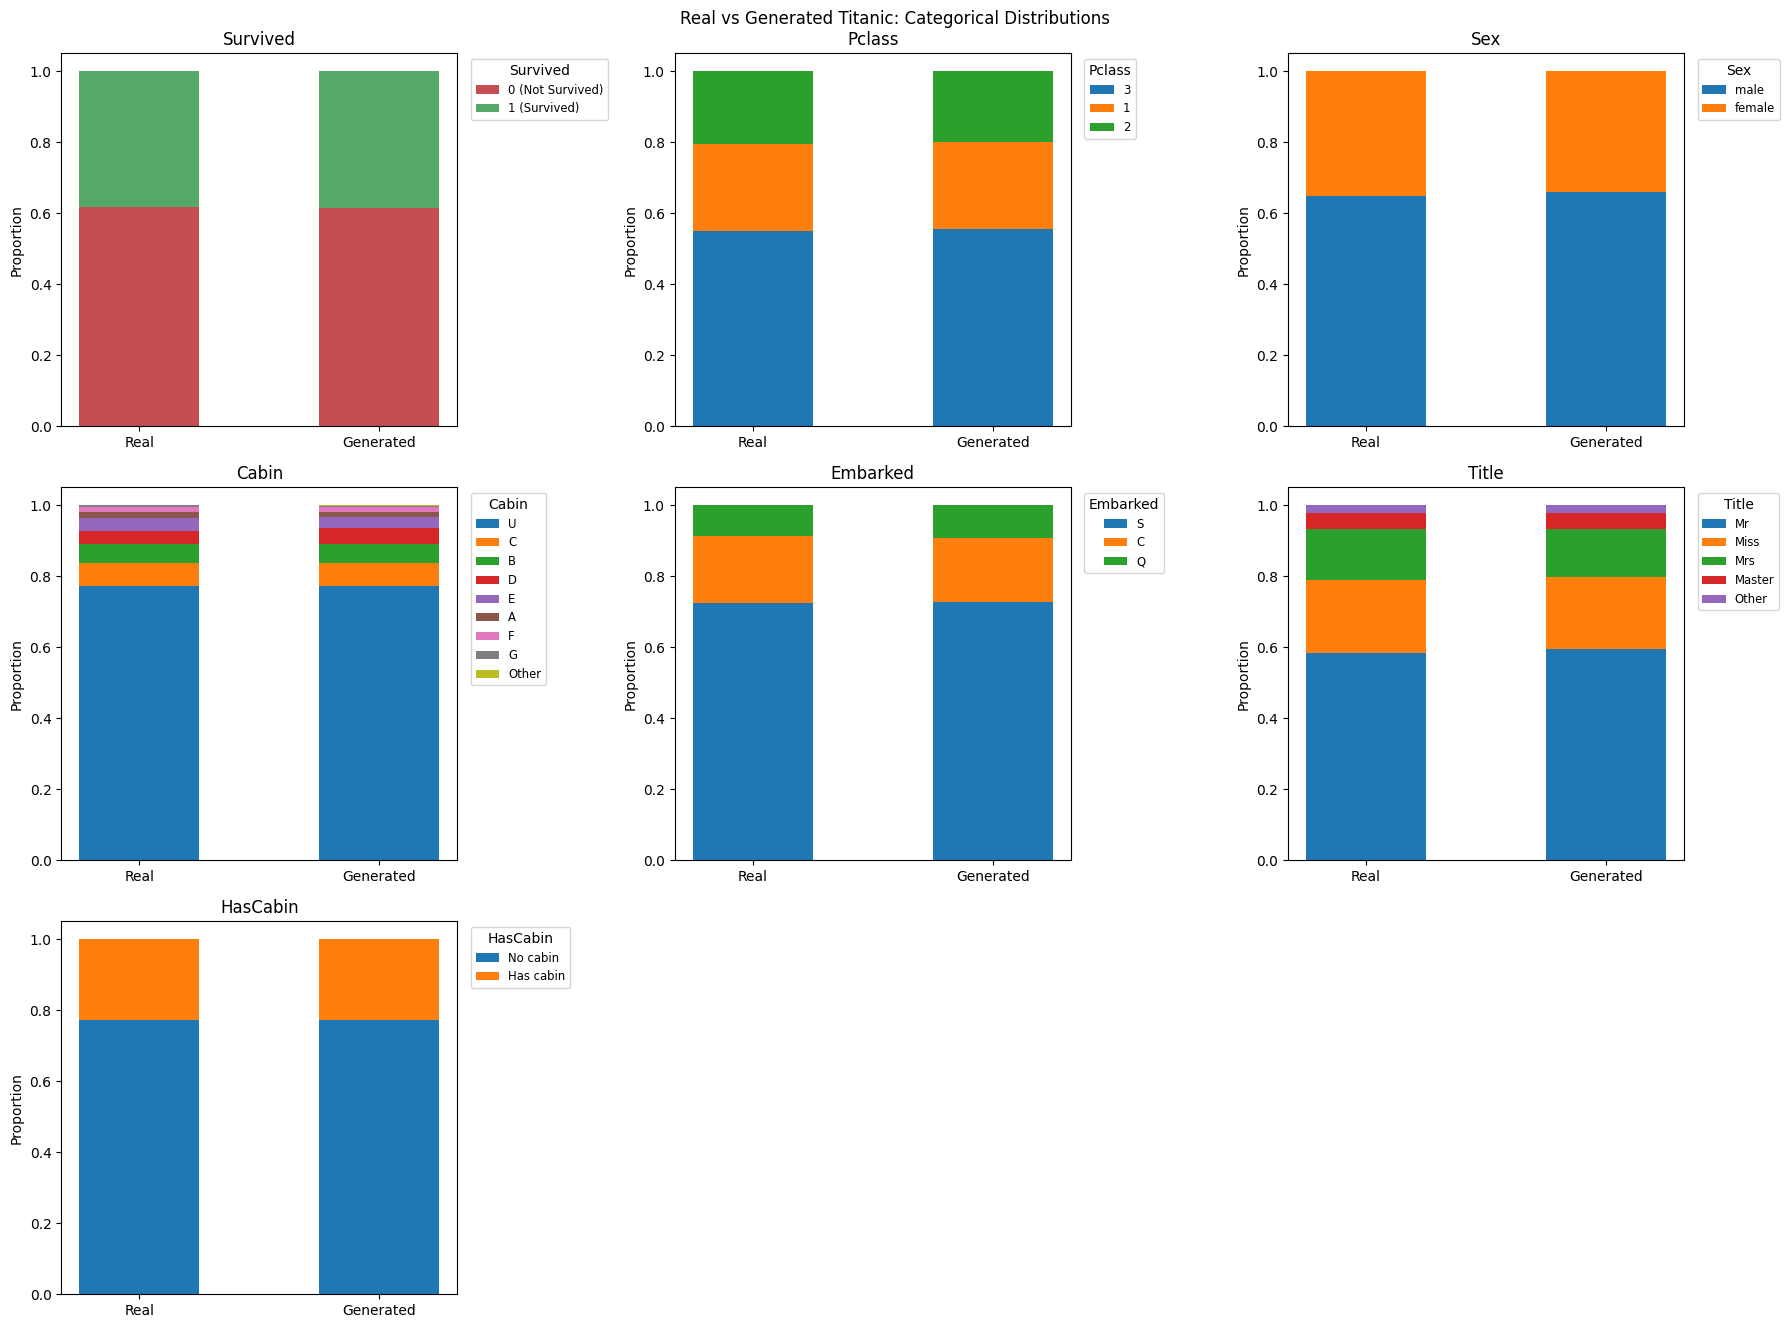

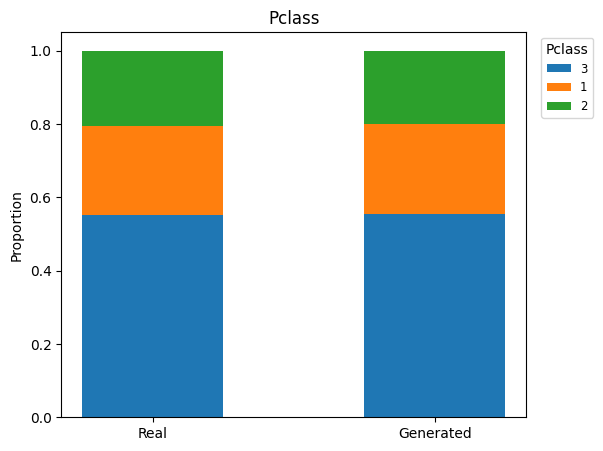

In [23]:
columns = ["Survived", "Pclass", "Sex", "Cabin", "Embarked", "Title", "HasCabin"]

styles = {
    "Survived": {
        "labels": {"0": "0 (Not Survived)", "1": "1 (Survived)"},
        "colors": {"0": "#C44E52", "1": "#55A868"},
    },
    "HasCabin": {"labels": {"0": "No cabin", "1": "Has cabin"}},
}

plot_all_comparisons(titanic_df, generated_titanic_df, columns, styles=styles)

# A single column on its own:
plot_stacked_comparison(titanic_df, generated_titanic_df, "Pclass")
plt.show()